In [1]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"h9-tec","key":"KGAT_193aad96759a47134c020b3334a45eb1"}')

os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d nechbamohammed/research-papers-dataset
!unzip -q research-papers-dataset.zip

import pandas as pd
df = pd.read_csv('dblp-v10.csv', nrows=50000)
print(df.shape)
print(df.columns.tolist())

Dataset URL: https://www.kaggle.com/datasets/nechbamohammed/research-papers-dataset
License(s): unknown
100% 590M/590M [00:07<00:00, 78.7MB/s]

(50000, 8)
['abstract', 'authors', 'n_citation', 'references', 'title', 'venue', 'year', 'id']


=== Missing Values ===
abstract      1889
authors          0
n_citation       0
references    1368
title            0
venue         4506
year             0
id               0
dtype: int64

=== Basic Stats ===
Years range: 1937 - 2017
Avg citations: 57.1
Papers with abstract: 48111

=== Top 10 Venues ===
venue
international conference on acoustics, speech, and signal processing    922
international conference on robotics and automation                     833
Bioinformatics                                                          535
international conference on communications                              531
intelligent robots and systems                                          518
international conference on image processing                            502
global communications conference                                        476
IEEE Transactions on Signal Processing                                  429
international symposium on circuits and systems                         423
inter

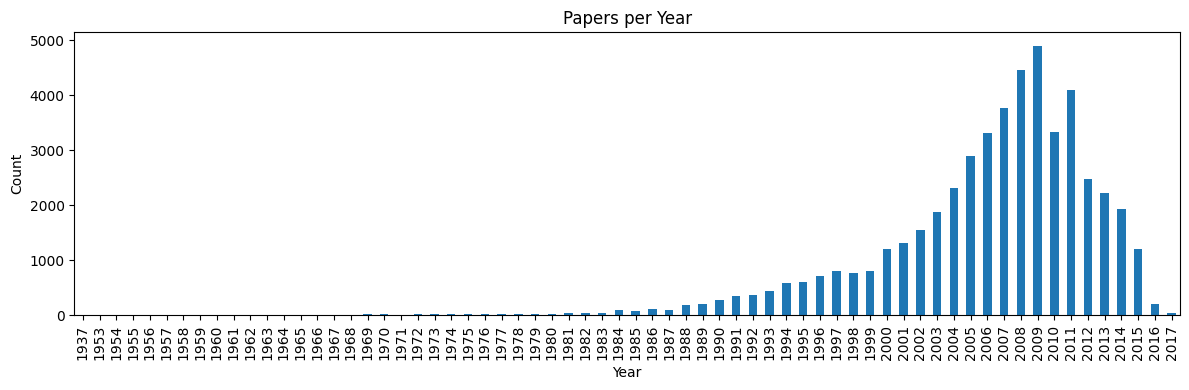

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Missing values
print("=== Missing Values ===")
print(df.isnull().sum())

# 2. Basic stats
print("\n=== Basic Stats ===")
print(f"Years range: {df['year'].min()} - {df['year'].max()}")
print(f"Avg citations: {df['n_citation'].mean():.1f}")
print(f"Papers with abstract: {df['abstract'].notna().sum()}")

# 3. Top venues
print("\n=== Top 10 Venues ===")
print(df['venue'].value_counts().head(10))

# 4. Papers per year
plt.figure(figsize=(12, 4))
df['year'].value_counts().sort_index().plot(kind='bar')
plt.title('Papers per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [3]:
# Data Cleaning
print("=== Before Cleaning ===")
print(f"Total papers: {len(df)}")

#Remove null values
df = df.dropna(subset=['abstract'])
df = df.dropna(subset=['title'])

# Clean Text
df['abstract'] = df['abstract'].str.strip()
df['title'] = df['title'].str.strip()

df['text'] = df['title'] + ' ' + df['abstract']

print(f"After cleaning: {len(df)}")
print(f"\nSample:")
print(df[['title', 'abstract']].head(2))

=== Before Cleaning ===
Total papers: 50000
After cleaning: 48111

Sample:
                                               title  \
0  A new approach of 3D watermarking based on ima...   
1  Attractor neural networks with activity-depend...   

                                            abstract  
0  In this paper, a robust 3D triangular mesh wat...  
1  We studied an autoassociative neural network w...  


In [5]:
df.head()

,abstract,authors,n_citation,references,title,venue,year,id,text
0,"In this paper, a robust 3D triangular mesh wat...","['S. Ben Jabra', 'Ezzeddine Zagrouba']",50,"['09cb2d7d-47d1-4a85-bfe5-faa8221e644b', '10aa...",A new approach of 3D watermarking based on ima...,international symposium on computers and commu...,2008,4ab3735c-80f1-472d-b953-fa0557fed28b,A new approach of 3D watermarking based on ima...
1,We studied an autoassociative neural network w...,"['Joaquín J. Torres', 'Jesús M. Cortés', 'Joaq...",50,"['4017c9d2-9845-4ad2-ad5b-ba65523727c5', 'b118...",Attractor neural networks with activity-depend...,Neurocomputing,2007,4ab39729-af77-46f7-a662-16984fb9c1db,Attractor neural networks with activity-depend...
2,It is well-known that Sturmian sequences are t...,"['Genevi eve Paquin', 'Laurent Vuillon']",50,"['1c655ee2-067d-4bc4-b8cc-bc779e9a7f10', '2e4e...",A characterization of balanced episturmian seq...,Electronic Journal of Combinatorics,2007,4ab3a4cf-1d96-4ce5-ab6f-b3e19fc260de,A characterization of balanced episturmian seq...
3,One of the fundamental challenges of recognizi...,"['Yaser Sheikh', 'Mumtaz Sheikh', 'Mubarak Shah']",221,"['056116c1-9e7a-4f9b-a918-44eb199e67d6', '05ac...",Exploring the space of a human action,international conference on computer vision,2005,4ab3a98c-3620-47ec-b578-884ecf4a6206,Exploring the space of a human action One of t...
4,This paper generalizes previous optimal upper ...,"['Efraim Laksman', 'Håkan Lennerstad', 'Magnus...",0,"['01a765b8-0cb3-495c-996f-29c36756b435', '5dbc...",Generalized upper bounds on the minimum distan...,Ima Journal of Mathematical Control and Inform...,2015,4ab3b585-82b4-4207-91dd-b6bce7e27c4e,Generalized upper bounds on the minimum distan...


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pickle

# Train TF-IDF
print("Training TF-IDF...")
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(df['text'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

def recommend_tfidf(query, top_k=5):
    query_vec = tfidf.transform([query])
    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = scores.argsort()[-top_k:][::-1]
    results = df.iloc[top_indices][['title', 'abstract', 'year', 'n_citation']]
    results['score'] = scores[top_indices]
    return results

results = recommend_tfidf("deep learning for image classification")
print(results[['title', 'abstract', 'year', 'n_citation', 'score']].to_string())

Training TF-IDF...
TF-IDF matrix shape: (48111, 10000)
                                                                                                              title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [7]:
!pip install sentence-transformers -q

In [8]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load SBERT model
print("Loading SBERT model...")
sbert = SentenceTransformer('all-MiniLM-L6-v2')

# Encode all papers
print("Encoding papers")
sbert_embeddings = sbert.encode(
    df['text'].tolist(),
    batch_size=64,
    show_progress_bar=True
)

print(f"Embeddings shape: {sbert_embeddings.shape}")

def recommend_sbert(query, top_k=5):
    query_emb = sbert.encode([query])
    scores = cosine_similarity(query_emb, sbert_embeddings).flatten()
    top_indices = scores.argsort()[-top_k:][::-1]
    results = df.iloc[top_indices][['title', 'abstract', 'year', 'n_citation']]
    results['score'] = scores[top_indices]
    return results

results = recommend_sbert("deep learning for image classification")
print(results[['title', 'score']].to_string())

Loading SBERT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding papers


Batches:   0%|          | 0/752 [00:00<?, ?it/s]

Embeddings shape: (48111, 384)
                                                                            title     score
39593                 Semantic-Sensitive Classification for Large Image Libraries  0.522859
45857                       Efficient object category recognition using classemes  0.506900
43647      Using Growing Neural Gas Networks to Represent Visual Object Knowledge  0.505046
18821                             Latent pyramidal regions for recognizing scenes  0.501763
36108  Foveal automatic target recognition using a multiresolution neural network  0.495500
